# 전기차 주행거리 예측

데이터사이언스학과 김은영

## 1. 문제 정의

전기차의 배터리 용량, 효율, 최고속도, 차체 크기 등 다양한 차량 정보를 바탕으로 주행거리를 예측하는 선형 회귀 모델을 구현한다. <br>
이를 통해 주행거리에 영향을 주는 주요 요인을 확인하고, 전기차의 성능 정보만으로 예상 주행거리를 예측한다.

y = f(x)
- y: 전기차 주행거리
- x: 주행거리에 영향을 주는 특징들
- f: 회귀 모델(linear regression)

## 2. 데이터 수집

캐글 데이터 수집 <br>
https://www.kaggle.com/datasets/urvishahir/electric-vehicle-specifications-dataset-2025 <Br>
원본 데이터는 https://ev-database.org

## 3. 데이터 탐색

라이브러리 불러오기

In [1]:
# 라이브러리 불러오기
import pandas as pd # 데이터프레임 처리
import numpy as np # 수치 연산

# 시각화
import matplotlib.pyplot as plt # 그래프 출력
import seaborn as sns # 통계 시각화
%matplotlib inline

# 모델링
from sklearn.model_selection import train_test_split # 학습/테스트 데이터 분리
from sklearn import linear_model # 선형 회귀 모델
import statsmodels.api as sm # 통계 기반 회귀 분석 (p-value, 계수 등)
from sklearn.preprocessing import StandardScaler # 수치형 변수 표준화 (평균 0, 표준편차 1)


# 다중공선성 검사
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF 계산

# 모델 평가
from sklearn.metrics import mean_squared_error # MSE (평균 제곱 오차)
from math import sqrt # RMSE 계산용 제곱근
from sklearn.model_selection import KFold # K-겹 교차 검증
from sklearn.metrics import r2_score # R² (결정계수)

데이터셋 기본 정보 파악

In [2]:
# 사용할 데이터 셋 불러오기
df=pd.read_csv("data/electric_vehicles_spec_2025.csv")

In [3]:
# 데이터의 구성 확인
df.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


변수 의미 확인

1. brand: 자동차 브랜드명
2. model: 차량 모델명
3. car_body_type: 차체 유형 (해치백/SUV/세단 등)
4. segment: 차량 등급 (소형/중형/대형 등)
5. battery_capacity_kWh: 배터리의 총 에너지 저장 용량 (kWh)
6. number_of_cells: 배터리를 구성하는 셀의 개수
7. battery_type: 배터리의 기술적 유형 정보
8. efficiency_wh_per_km: 1km 주행 시 소비되는 전력량 (Wh/km)
9. range_km: 완전 충전 시 주행 가능 거리 (km)
10. fast_charging_power_kw_dc: 지원 가능한 최대 DC(직류 방식) 급속충전 전력 (kW)
11. fast_charge_port: 충전 커넥터 규격 (CCS/CHAdeMO)
12. top_speed_kmh: 최고 속도 (km/h)
13. acceleration_0_100_s: 정지 → 100 km/h 도달 시간 (s)
14. torque_nm: 차량이 바퀴를 돌릴 때 발생하는 최대 회전력 (차량이 앞으로 나가도록 바퀴를 돌리는 힘) 
15. towing_capacity_kg: 최대 견인 하중 (kg)
16. cargo_volume_l: 최대 견인 하중 (kg)
17. seats: 총 좌석 수
18. length_mm: 차량의 전장 (앞에서 뒤까지의 길이)
19. width_mm: 차량의 전폭 (왼쪽에서 오른쪽까지의 너비)
20. height_mm: 차량의 전고 (바닥에서 차 지붕까지의 높이)
21. drivetrain: 구동 방식(AWD, RWD, FWD)
22. source_url: 데이터 수집 원본 URL

In [4]:
### 그래프의 배경을 설정: sns --> seaborn 라이브러리 이용
sns.set_style('darkgrid')

In [5]:
# 데이터셋의 기본 정보 파악
df.shape

(478, 22)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    str    
 1   model                      477 non-null    str    
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    str    
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    str    
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    str    
 14  seats

In [7]:
# 결측치 확인
df.isnull().sum()

brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

<Axes: >

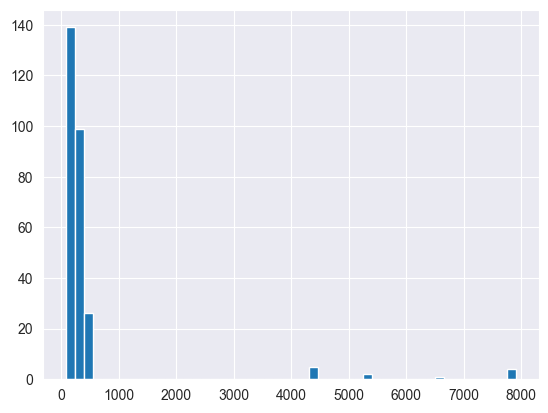

In [8]:
# 결측치 많은 컬럼 확인
df['number_of_cells'].hist(bins=50)

In [9]:
# 결측치가 많거나 분석에 필요 없는 컬럼 제거
df.drop(columns=['number_of_cells', 'source_url'], inplace=True)

In [10]:
# 결측치 있는 행 전부 삭제 
df.dropna(inplace=True)

In [11]:
# 데이터 타입 확인
df.info()

<class 'pandas.DataFrame'>
Index: 442 entries, 0 to 476
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      442 non-null    str    
 1   model                      442 non-null    str    
 2   top_speed_kmh              442 non-null    int64  
 3   battery_capacity_kWh       442 non-null    float64
 4   battery_type               442 non-null    str    
 5   torque_nm                  442 non-null    float64
 6   efficiency_wh_per_km       442 non-null    int64  
 7   range_km                   442 non-null    int64  
 8   acceleration_0_100_s       442 non-null    float64
 9   fast_charging_power_kw_dc  442 non-null    float64
 10  fast_charge_port           442 non-null    str    
 11  towing_capacity_kg         442 non-null    float64
 12  cargo_volume_l             442 non-null    str    
 13  seats                      442 non-null    int64  
 14  drivetrain

In [12]:
df.shape

(442, 20)

str 타입인 데이터 확인 필요.

In [13]:
### [통계] 수치형 변수만 뽑아서 기본 통계량 확인하기
df.describe()

,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,185.377828,74.549321,502.947964,163.674208,394.570136,6.857692,127.237557,1055.819005,5.298643,4686.033937,1888.330317,1605.721719
std,32.602878,20.234694,235.309165,34.773941,103.045114,2.693133,58.616554,733.450250,0.997252,363.916889,71.185233,130.436897
min,125.000000,21.300000,113.000000,109.000000,135.000000,2.200000,29.000000,0.000000,2.000000,3631.000000,1622.000000,1378.000000
25%,160.000000,60.000000,310.000000,143.000000,325.000000,4.800000,80.000000,500.000000,5.000000,4456.250000,1849.000000,1516.000000
50%,180.000000,77.000000,440.000000,155.500000,400.000000,6.500000,115.000000,1000.000000,5.000000,4721.500000,1890.000000,1603.000000
75%,201.000000,90.600000,679.000000,178.000000,470.000000,8.200000,150.000000,1600.000000,5.000000,4961.000000,1939.000000,1665.000000
max,305.000000,118.000000,1340.000000,370.000000,685.000000,19.100000,281.000000,2500.000000,9.000000,5908.000000,2019.000000,1986.000000


str 타입 데이터 확인

In [14]:
num_brand=df['brand'].unique()
print(len(num_brand))
num_brand

52


<StringArray>
[       'Abarth',          'Alfa',        'Alpine',          'Audi',
           'BMW',           'BYD',         'CUPRA',      'Cadillac',
       'Citroen',            'DS',         'Dacia',          'Fiat',
          'Ford',           'GWM',       'Genesis',         'Honda',
        'Hongqi',       'Hyundai',        'Jaguar',          'Jeep',
           'KGM',           'Kia',        'Lancia',     'Leapmotor',
         'Lexus',         'Lotus',         'Lucid',       'Lynk&Co',
            'MG',      'Maserati',         'Maxus',         'Mazda',
 'Mercedes-Benz',          'Mini',           'NIO',        'Nissan',
          'Opel',       'Peugeot',      'Polestar',       'Porsche',
       'Renault',         'Skoda',         'Smart',        'Subaru',
         'Tesla',        'Toyota',       'VinFast',    'Volkswagen',
         'Volvo',         'Voyah',         'XPENG',         'Zeekr']
Length: 52, dtype: str

In [15]:
num_model=df['model'].unique()
print(len(num_model))
num_model

442


<StringArray>
[                    '500e Convertible',
                       '500e Hatchback',
                  '600e Scorpionissima',
                         '600e Turismo',
        'Romeo Junior Elettrica 54 kWh',
 'Romeo Junior Elettrica 54 kWh Veloce',
                 'A290 Electric 180 hp',
                 'A290 Electric 220 hp',
                      'A6 Avant e-tron',
          'A6 Avant e-tron performance',
 ...
                      'P7 Wing Edition',
                   '001 Long Range RWD',
                  '001 Performance AWD',
                    '001 Privilege AWD',
                    '7X Long Range RWD',
                   '7X Performance AWD',
                       '7X Premium RWD',
                    'X Core RWD (MY25)',
              'X Long Range RWD (MY25)',
               'X Privilege AWD (MY25)']
Length: 442, dtype: str

In [16]:
num_battery_type=df['battery_type'].unique()
print(len(num_battery_type))
num_battery_type

1


<StringArray>
['Lithium-ion']
Length: 1, dtype: str

In [17]:
num_fast_charge_port=df['fast_charge_port'].unique()
print(len(num_fast_charge_port))
num_fast_charge_port

2


<StringArray>
['CCS', 'CHAdeMO']
Length: 2, dtype: str

In [18]:
num_cargo_volume_l=df['cargo_volume_l'].unique()
print(len(num_cargo_volume_l))
num_cargo_volume_l

127


<StringArray>
[            '185',             '360',             '400',             '326',
             '502',             '520',             '535',             '526',
             '511', '10 Banana Boxes',
 ...
             '543',             '549',             '532',             '605',
             '404',             '318',             '571',             '660',
             '539',             '362']
Length: 127, dtype: str

In [19]:
num_drivetrain=df['drivetrain'].unique()
print(len(num_drivetrain))
num_drivetrain

3


<StringArray>
['FWD', 'RWD', 'AWD']
Length: 3, dtype: str

In [20]:
num_segment=df['segment'].unique()
print(len(num_segment))
num_segment

12


<StringArray>
[      'B - Compact',      'JB - Compact',    'JE - Executive',
       'JC - Medium',        'JD - Large',        'F - Luxury',
         'D - Large',     'E - Executive',        'C - Medium',
       'JF - Luxury', 'N - Passenger Van',          'A - Mini']
Length: 12, dtype: str

In [21]:
num_car_body_type=df['car_body_type'].unique()
print(len(num_car_body_type))
num_car_body_type

7


<StringArray>
[          'Hatchback',                 'SUV',      'Station/Estate',
      'Liftback Sedan',               'Sedan', 'Small Passenger Van',
           'Cabriolet']
Length: 7, dtype: str

종속변수(range_km) 탐색

In [22]:
# 종속 변수 탐색 (range_km) 
# 기초통계량 확인
df['range_km'].describe()

count    442.000000
mean     394.570136
std      103.045114
min      135.000000
25%      325.000000
50%      400.000000
75%      470.000000
max      685.000000
Name: range_km, dtype: float64

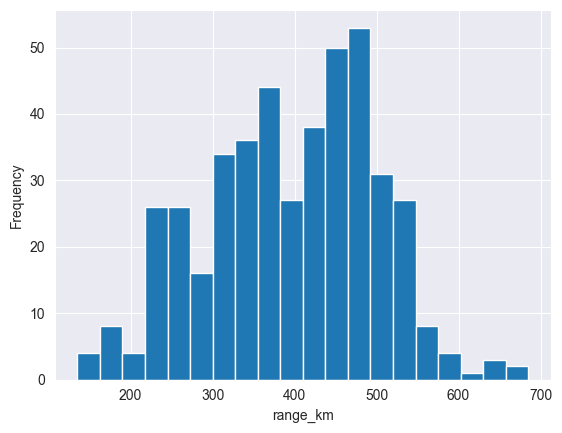

In [23]:
# 데이터의 분포를 파악
# x축은 주행 거리 
# y축은 빈도수(frequency)
df['range_km'].hist(bins=20)
plt.xlabel('range_km')
plt.ylabel('Frequency')
plt.show()

C:\Users\keyou\AppData\Local\Temp\ipykernel_29988\505701778.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['range_km'], labels=['range_km'])


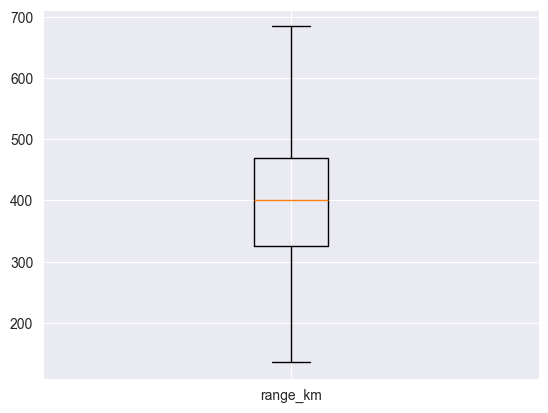

In [24]:
# 박스 플롯(boxplot)을 이용한 아웃라이어 탐색
plt.boxplot(df['range_km'], labels=['range_km'])
plt.show()

독립 변수(x) 탐색

In [25]:
df.columns

Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km',
       'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port',
       'towing_capacity_kg', 'cargo_volume_l', 'seats', 'drivetrain',
       'segment', 'length_mm', 'width_mm', 'height_mm', 'car_body_type'],
      dtype='str')

C:\Users\keyou\AppData\Local\Temp\ipykernel_29988\4141543447.py:20: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[numerical_columns].hist(ax=ax)


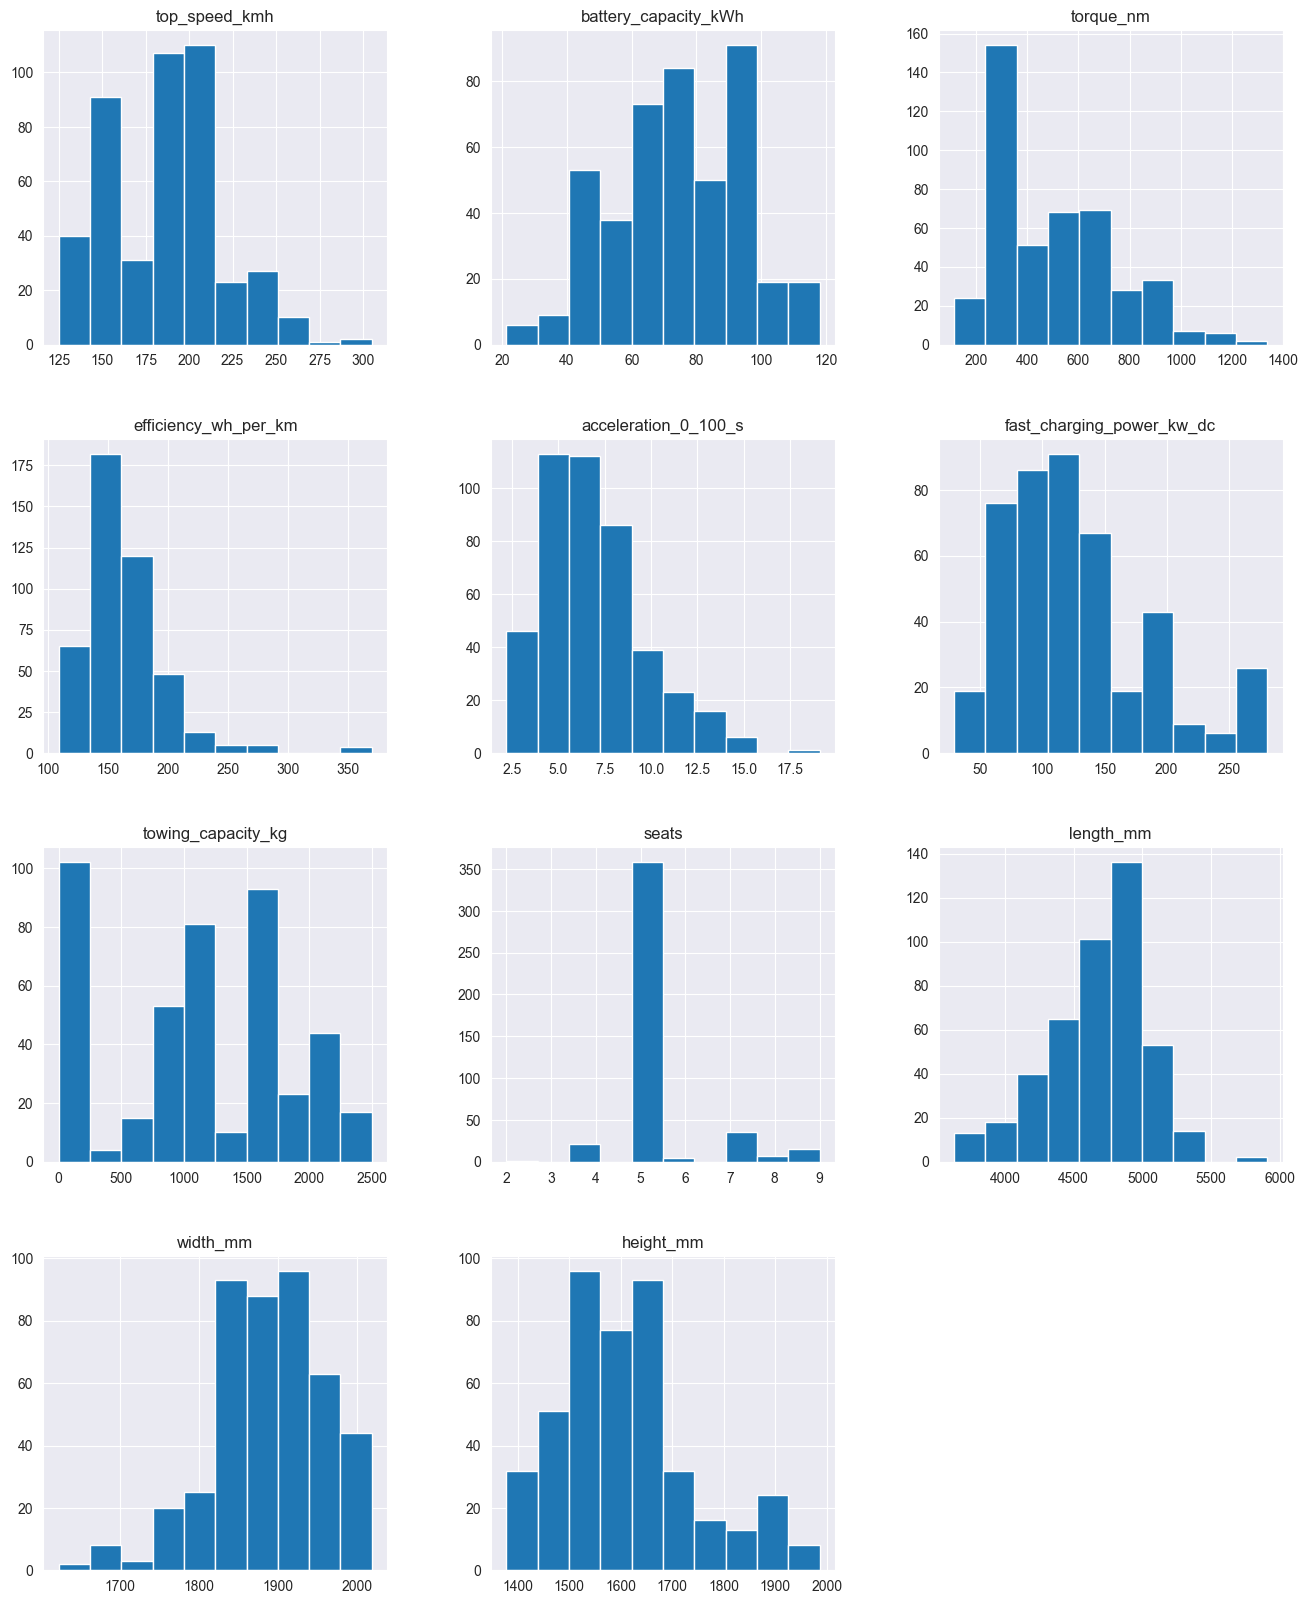

In [26]:
# 독립 변수 탐색
# numerical features (except str data type, range_km(종속 변수))
numerical_columns = [
    'top_speed_kmh',           # int64
    'battery_capacity_kWh',    # float64
    'torque_nm',               # float64
    'efficiency_wh_per_km',    # int64
    'acceleration_0_100_s',    # float64
    'fast_charging_power_kw_dc', # float64
    'towing_capacity_kg',      # float64
    'seats',                   # int64
    'length_mm',               # int64
    'width_mm',                # int64
    'height_mm'                # int64
]

# 수치형 독립 변수 분포 시각화
fig = plt.figure(figsize = (16, 20))
ax = fig.gca()  
df[numerical_columns].hist(ax=ax)
plt.show()

변수들 간의 관계 탐색

In [27]:
# 피어쓴(Pearson) 상관계수
cols = [
    'range_km',                # int64  ← y (종속변수)
    'top_speed_kmh',           # int64
    'battery_capacity_kWh',    # float64
    'torque_nm',               # float64
    'efficiency_wh_per_km',    # int64
    'acceleration_0_100_s',    # float64
    'fast_charging_power_kw_dc', # float64
    'towing_capacity_kg',      # float64
    'seats',                   # int64
    'length_mm',               # int64
    'width_mm',                # int64
    'height_mm'                # int64
]

corr = df[cols].corr(method = 'pearson')
corr

,range_km,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
range_km,1.000000,0.744226,0.877989,0.662811,0.005422,-0.703811,0.725452,0.334974,-0.285720,0.468615,0.506245,-0.425054
top_speed_kmh,0.744226,1.000000,0.712520,0.784957,0.149214,-0.820093,0.787857,0.216897,-0.360493,0.408022,0.512533,-0.474455
battery_capacity_kWh,0.877989,0.712520,1.000000,0.764957,0.367961,-0.625363,0.727873,0.447279,-0.007980,0.669770,0.728229,-0.058395
torque_nm,0.662811,0.784957,0.764957,1.000000,0.348875,-0.784100,0.648793,0.348131,-0.169647,0.490222,0.562993,-0.187653
efficiency_wh_per_km,0.005422,0.149214,0.367961,0.348875,1.000000,-0.034869,0.165543,0.242598,0.543184,0.654865,0.585201,0.522337
acceleration_0_100_s,-0.703811,-0.820093,-0.625363,-0.784100,-0.034869,1.000000,-0.623059,-0.281225,0.491034,-0.193627,-0.349926,0.510742
fast_charging_power_kw_dc,0.725452,0.787857,0.727873,0.648793,0.165543,-0.623059,1.000000,0.234266,-0.160921,0.458176,0.579606,-0.303452
towing_capacity_kg,0.334974,0.216897,0.447279,0.348131,0.242598,-0.281225,0.234266,1.000000,0.139297,0.395670,0.464808,0.297927
seats,-0.285720,-0.360493,-0.007980,-0.169647,0.543184,0.491034,-0.160921,0.139297,1.000000,0.474941,0.315731,0.702816
length_mm,0.468615,0.408022,0.669770,0.490222,0.654865,-0.193627,0.458176,0.395670,0.474941,1.000000,0.846910,0.276030


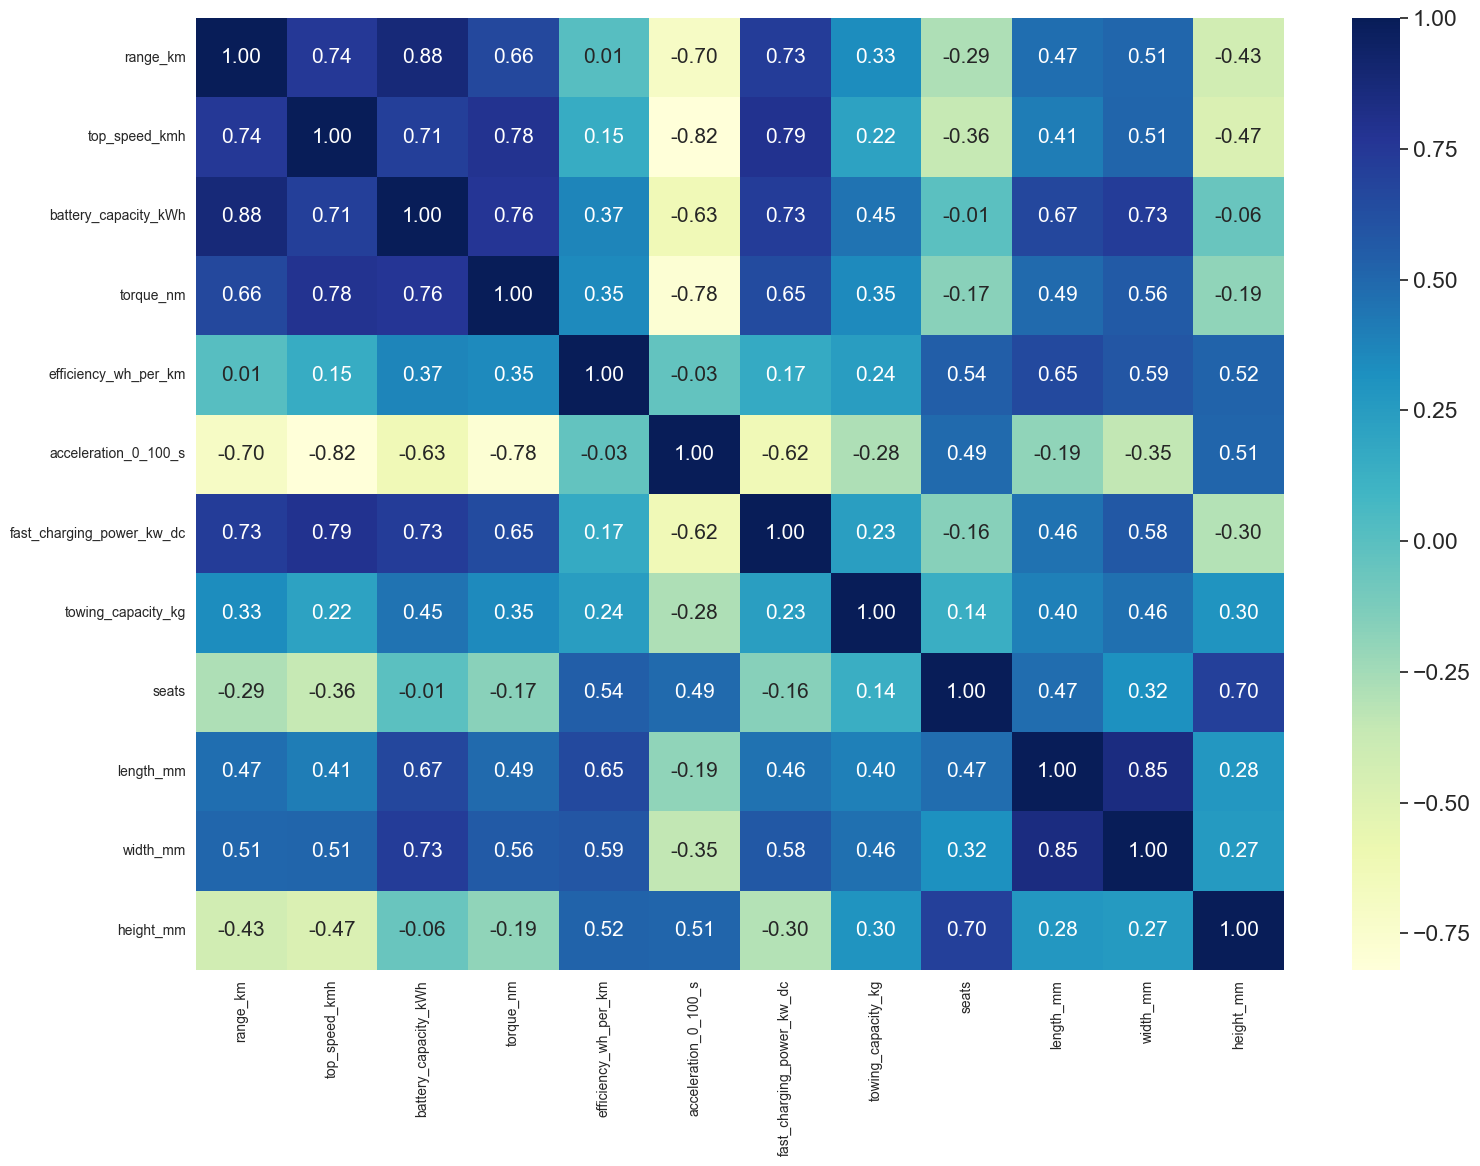

In [28]:
# 히트맵(heatmap)으로 상관관계 시각화
fig = plt.figure(figsize = (16, 12))
ax = fig.gca()

sns.set(font_scale = 1.5)
heatmap = sns.heatmap(corr.values, annot = True, fmt='.2f', 
                      annot_kws={'size':15},
                      yticklabels = cols, xticklabels = cols, 
                      ax=ax, cmap = "YlGnBu")
plt.tight_layout() 

plt.show()

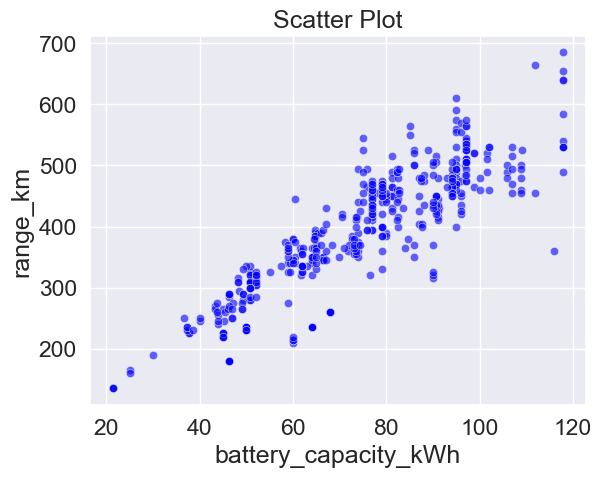

In [29]:
# 종속변수와 양의 상관관계를 가진 battery_capacity_kWh 산점도로 시각화
sns.scatterplot(data=df, 
                x='battery_capacity_kWh', y='range_km', 
                markers='o', 
                color='blue',
                alpha=0.6)
plt.title('Scatter Plot')
plt.show()

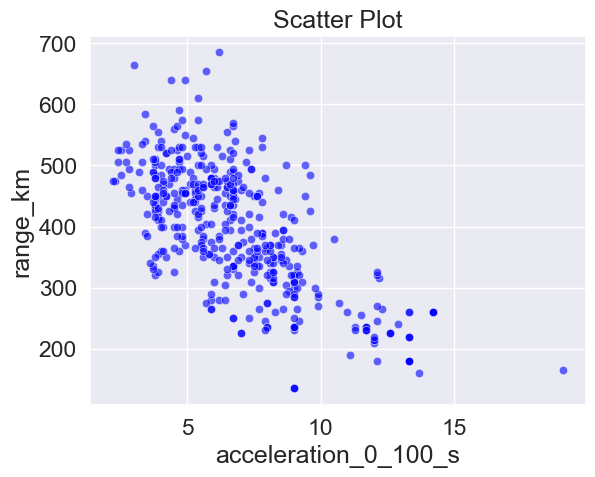

In [30]:
# 종속변수와 음의 상관관계를 가진 acceleration_0_100_s 산점도로 시각화
sns.scatterplot(data=df,
                x='acceleration_0_100_s', y='range_km', 
                markers='o', 
                color='blue', 
                alpha=0.6)
plt.title('Scatter Plot')
plt.show()

In [31]:
# 각 브랜드에 따른 데이터 개수 확인
df['brand'].value_counts()

brand
Mercedes-Benz    42
Audi             28
Porsche          26
Volkswagen       23
Ford             21
BMW              20
Volvo            18
Smart            17
BYD              16
Peugeot          15
Opel             14
Citroen          12
Hyundai          12
Kia              12
NIO              12
Skoda            12
MG               10
Renault          10
Polestar          9
XPENG             9
Zeekr             9
Fiat              8
Mini              8
Tesla             7
Toyota            7
GWM               6
Lotus             6
CUPRA             5
DS                5
Nissan            5
Abarth            4
Genesis           4
Hongqi            3
Lexus             3
Alfa              2
Alpine            2
Dacia             2
Jeep              2
Mazda             2
VinFast           2
Cadillac          1
Honda             1
Jaguar            1
KGM               1
Lancia            1
Leapmotor         1
Lucid             1
Lynk&Co           1
Maserati          1
Maxus         

C:\Users\keyou\AppData\Local\Temp\ipykernel_29988\1890566092.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # 직접 ax에 적용


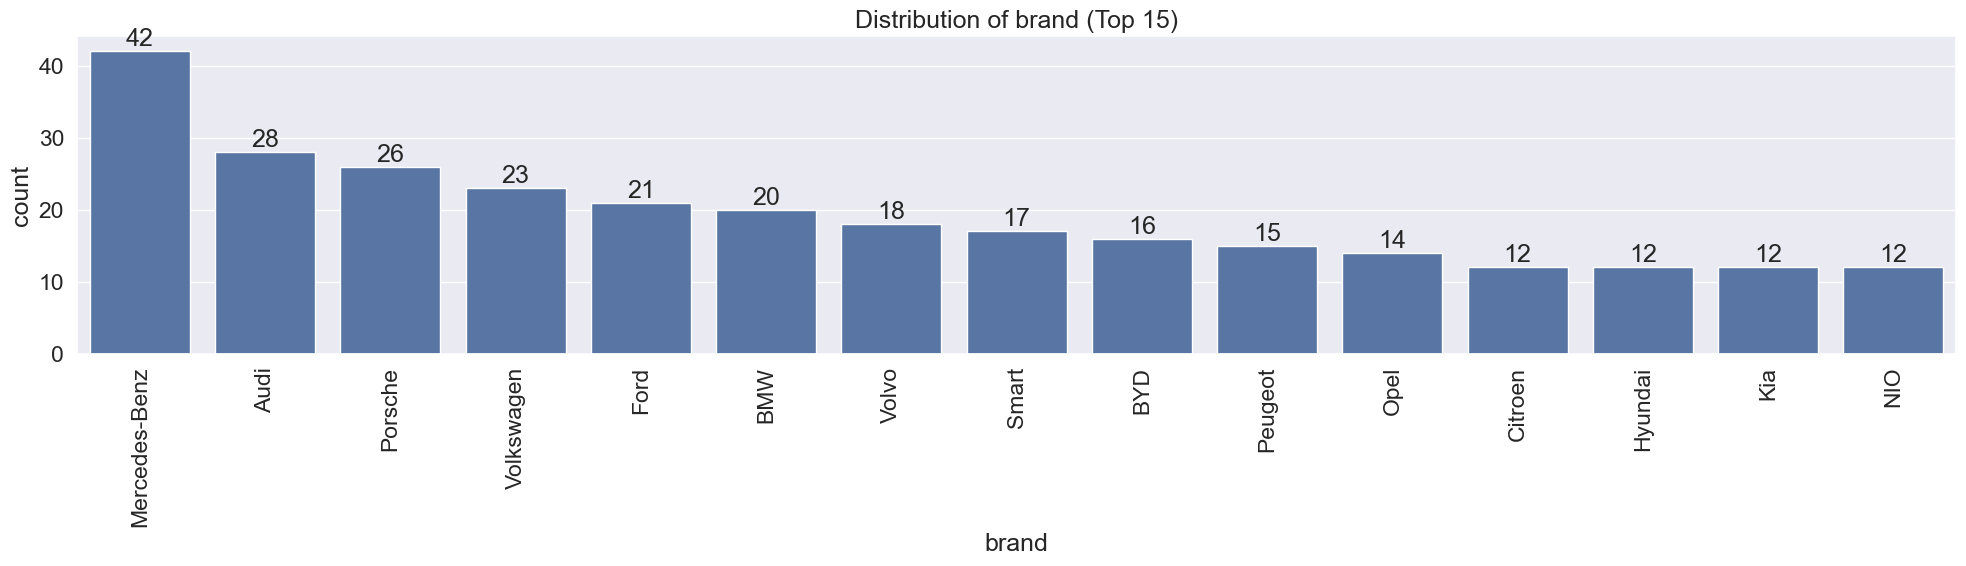

In [32]:
# brand별 데이터 개수 확인 (상위 15개)
plt.figure(figsize=(20, 6))

top15 = df['brand'].value_counts().head(15).index

ax = sns.countplot(x='brand', order=top15, data=df[df['brand'].isin(top15)])
plt.title('Distribution of brand (Top 15)')

for rect in ax.patches:
    height = rect.get_height()
    if height > 0:
        ax.text(rect.get_x() + rect.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # 직접 ax에 적용

plt.tight_layout()
plt.show()

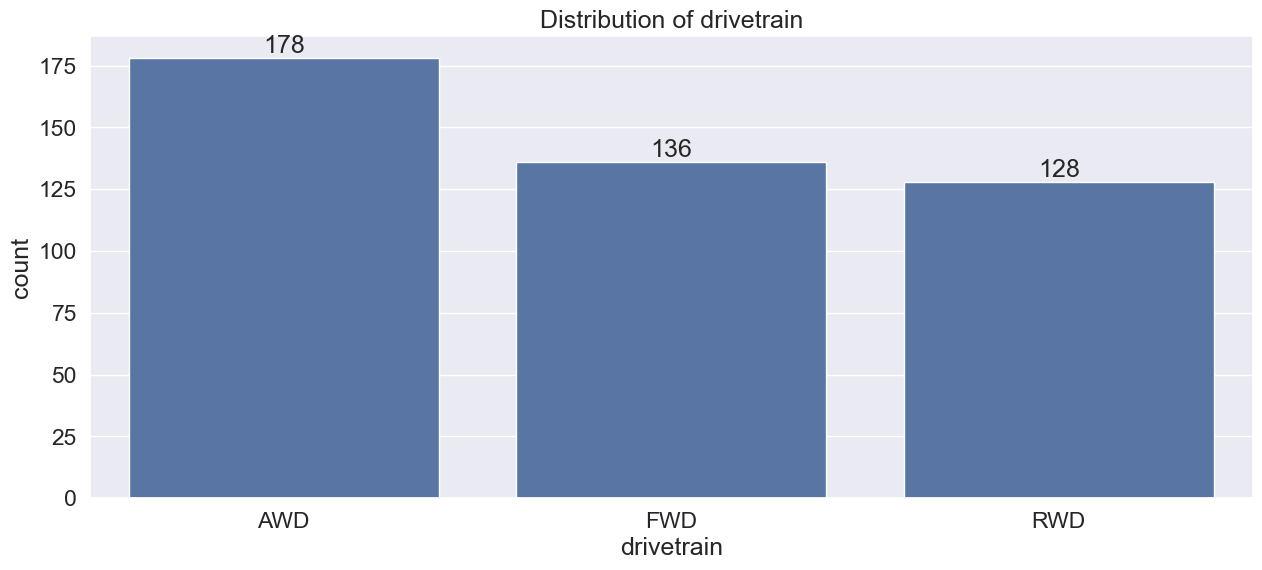

In [33]:
# drivetrain별 데이터 개수 확인
plt.figure(figsize=(15, 6))

sns.countplot(x='drivetrain', order=df['drivetrain'].value_counts().index, data=df)
plt.title('Distribution of drivetrain')

# 막대 위에 값 표시하기
for rect in plt.gca().patches:
    height = rect.get_height()
    if height > 0:
        plt.gca().text(rect.get_x() + rect.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.show()

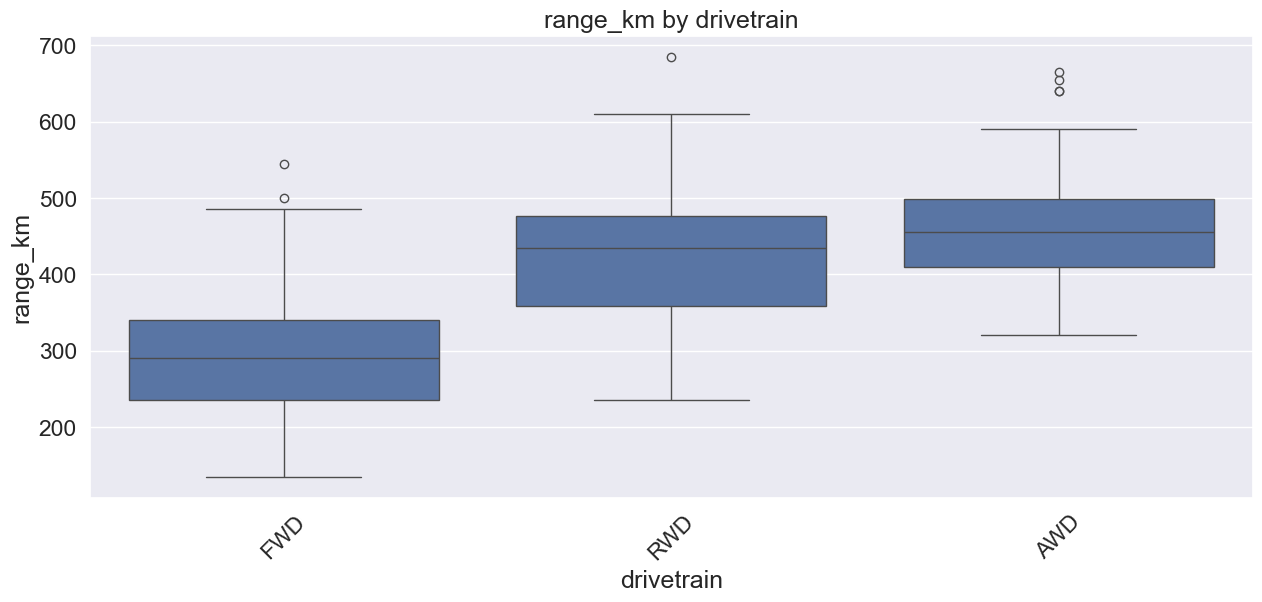

In [34]:
# drivetrain별 주행거리 박스플롯
plt.figure(figsize=(15, 6))
sns.boxplot(x='drivetrain', y='range_km', data=df)
plt.title('range_km by drivetrain')
plt.xticks(rotation=45)
plt.show()

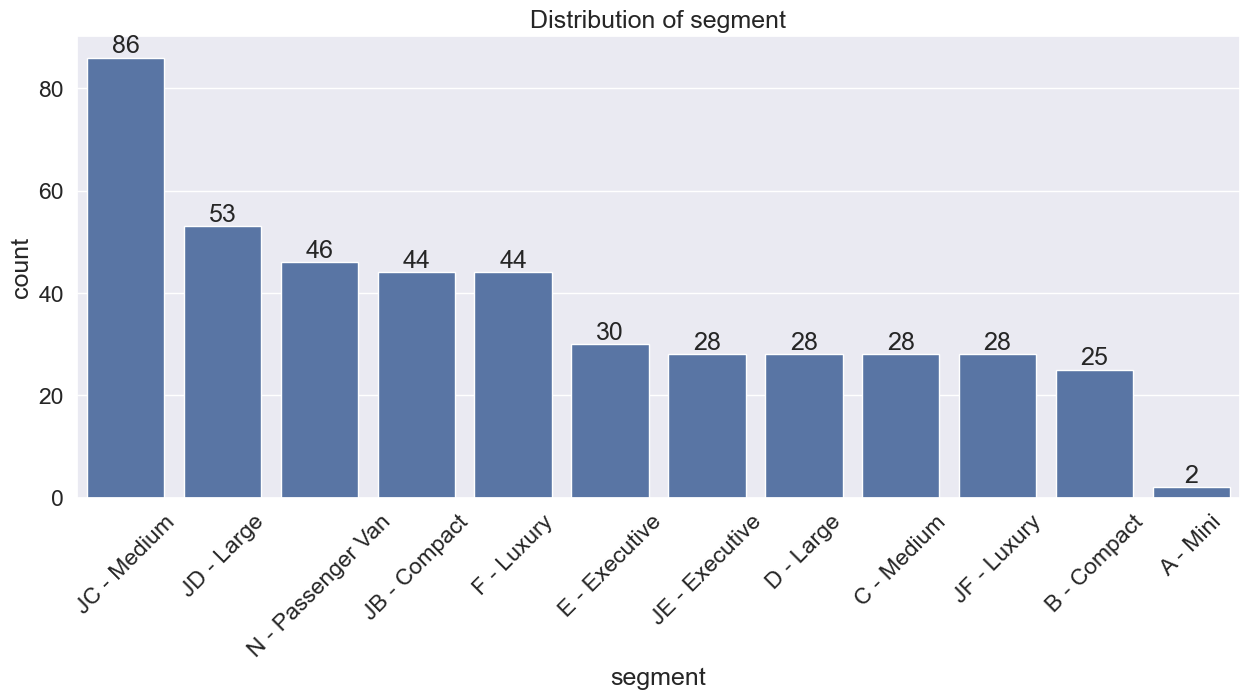

In [35]:
# segment별 데이터 개수 확인
plt.figure(figsize=(15, 6))
sns.countplot(x='segment', order=df['segment'].value_counts().index, data=df)
plt.title('Distribution of segment')
plt.xticks(rotation=45)

for rect in plt.gca().patches:
    height = rect.get_height()
    if height > 0:
        plt.gca().text(rect.get_x() + rect.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.show()

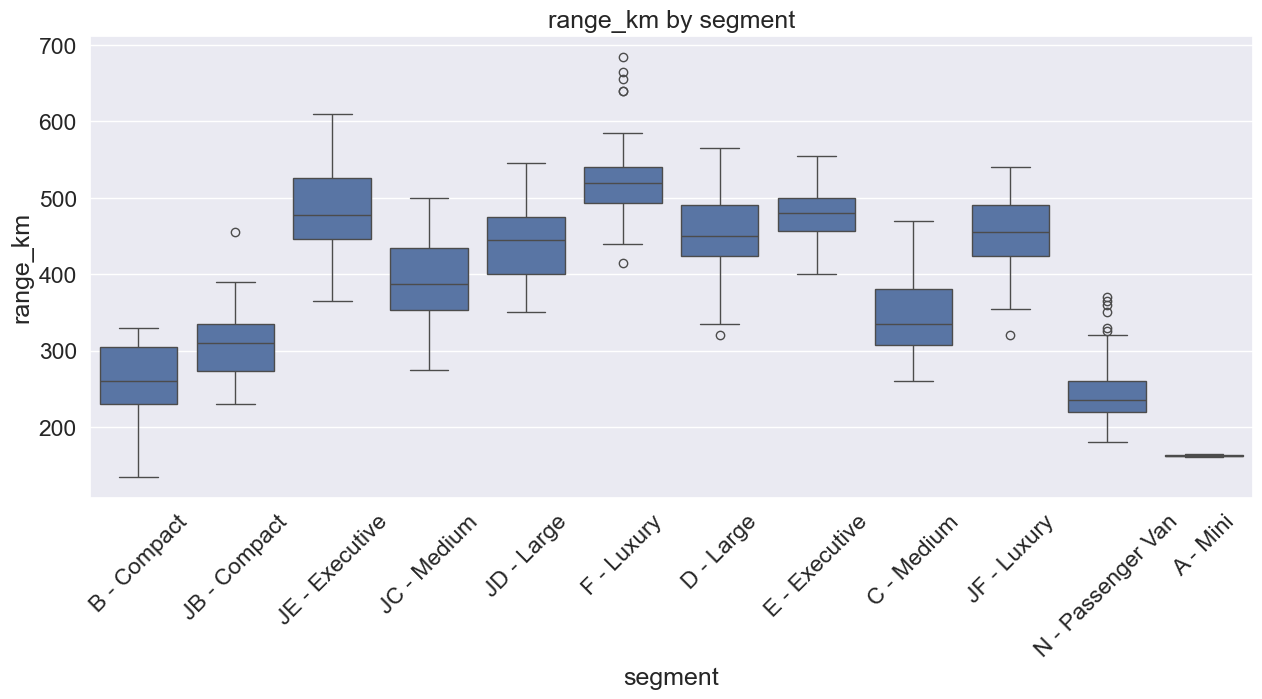

In [36]:
# segment별 주행거리 박스플롯
plt.figure(figsize=(15, 6))
sns.boxplot(x='segment', y='range_km', data=df)
plt.title('range_km by segment')
plt.xticks(rotation=45)
plt.show()

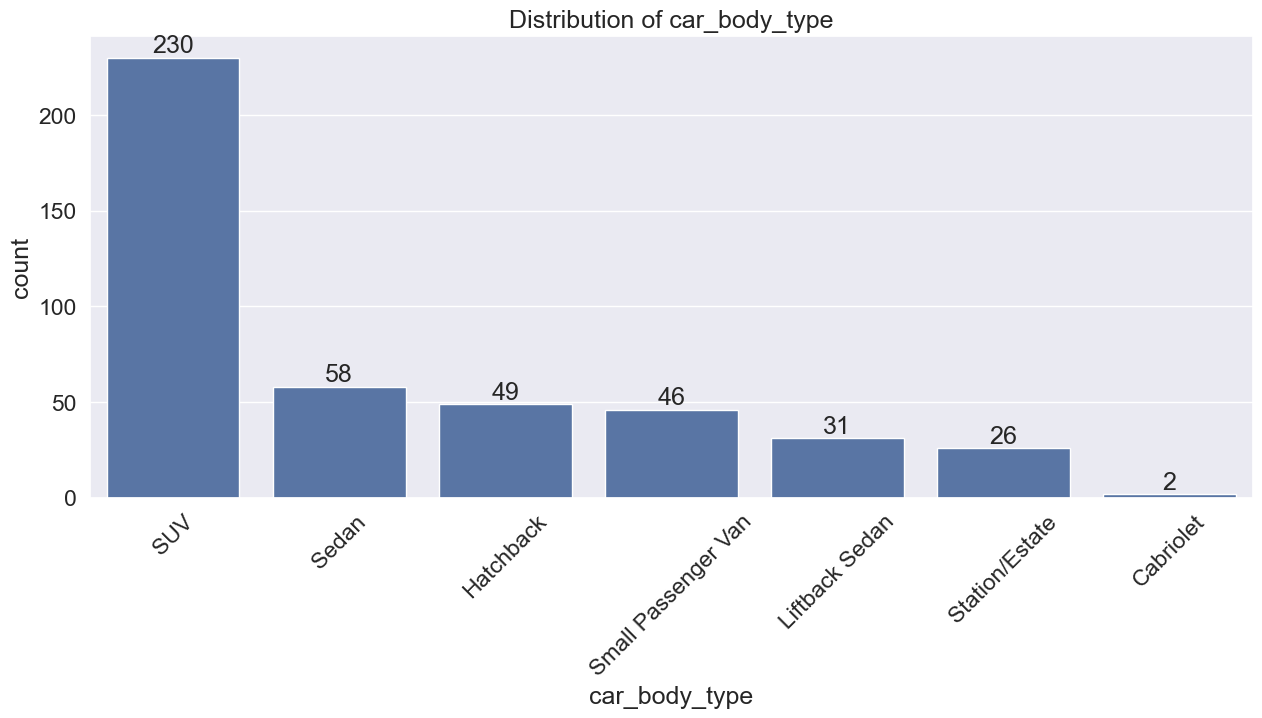

In [37]:
# car_body_type별 데이터 개수 확인
plt.figure(figsize=(15, 6))
sns.countplot(x='car_body_type', order=df['car_body_type'].value_counts().index, data=df)
plt.title('Distribution of car_body_type')
plt.xticks(rotation=45)

for rect in plt.gca().patches:
    height = rect.get_height()
    if height > 0:
        plt.gca().text(rect.get_x() + rect.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.show()

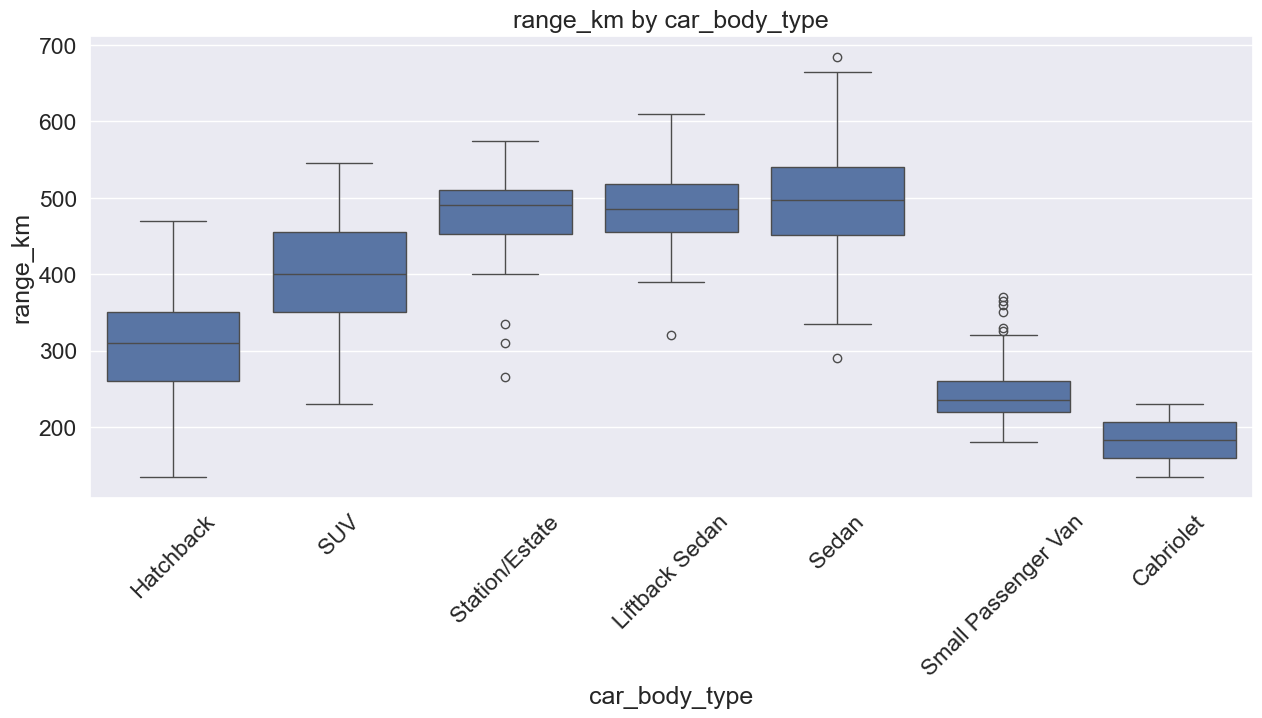

In [38]:
# car_body_type별 주행거리 박스플롯
plt.figure(figsize=(15, 6))
sns.boxplot(x='car_body_type', y='range_km', data=df)
plt.title('range_km by car_body_type')
plt.xticks(rotation=45)
plt.show()

## 4. 데이터 전처리

In [39]:
df.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,fast_charge_port,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type
0,Abarth,500e Convertible,155,37.8,Lithium-ion,235.0,156,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,235.0,149,225,7.0,67.0,CCS,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,345.0,158,280,5.9,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV
3,Abarth,600e Turismo,200,50.8,Lithium-ion,345.0,158,280,6.2,79.0,CCS,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV
6,Alfa,Romeo Junior Elettrica 54 kWh,150,50.8,Lithium-ion,260.0,128,320,9.0,85.0,CCS,0.0,400,5,FWD,JB - Compact,4173,1781,1532,SUV


In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 442 entries, 0 to 476
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      442 non-null    str    
 1   model                      442 non-null    str    
 2   top_speed_kmh              442 non-null    int64  
 3   battery_capacity_kWh       442 non-null    float64
 4   battery_type               442 non-null    str    
 5   torque_nm                  442 non-null    float64
 6   efficiency_wh_per_km       442 non-null    int64  
 7   range_km                   442 non-null    int64  
 8   acceleration_0_100_s       442 non-null    float64
 9   fast_charging_power_kw_dc  442 non-null    float64
 10  fast_charge_port           442 non-null    str    
 11  towing_capacity_kg         442 non-null    float64
 12  cargo_volume_l             442 non-null    str    
 13  seats                      442 non-null    int64  
 14  drivetrain

범주형 변수 처리

데이터셋의 세부 차량 등급(Mini, Compact, Medium, Large, Executive, Luxury, Passenger Van)이 많아 해석이 복잡하므로, <Br>
차량 차급의 유사성을 기준으로 3개 범주(Small / Medium / Large)로 재분류 <Br>
접두사가 붙은 항목은 동일한 등급명에 대응하므로 같은 범주로 처리

1. 'segment' 맵핑하기

- Small: 소형 (Mini, Compact) <br>
- Medium: 중형 (Medium) <br>
- Large: 대형 (Large, Executive, Luxury, Van)

In [41]:
df['segment'].unique()

<StringArray>
[      'B - Compact',      'JB - Compact',    'JE - Executive',
       'JC - Medium',        'JD - Large',        'F - Luxury',
         'D - Large',     'E - Executive',        'C - Medium',
       'JF - Luxury', 'N - Passenger Van',          'A - Mini']
Length: 12, dtype: str

In [42]:
# segment 맵핑
segment_map = {
    'A - Mini': 'Small',
    'B - Compact': 'Small',
    'C - Medium': 'Medium',
    'JB - Compact': 'Small',
    'JC - Medium': 'Medium',
    'D - Large': 'Large',
    'E - Executive': 'Large',
    'F - Luxury': 'Large',
    'JD - Large': 'Large',
    'JE - Executive': 'Large',
    'JF - Luxury': 'Large',
    'N - Passenger Van': 'Large'
}

df['segment'] = df['segment'].map(segment_map)
print(df['segment'].unique())

<StringArray>
['Small', 'Large', 'Medium']
Length: 3, dtype: str


2. 원핫인코딩

In [43]:
# drivetrain, segment 범주형 변수들 원핫인코딩
# drop_first=True: 다중공선성 방지를 위해 각 카테고리의 첫 번째 컬럼 제거
df = pd.get_dummies(df, columns=['drivetrain', 'segment'], dtype=int, drop_first=True)

In [44]:
df.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,...,cargo_volume_l,seats,length_mm,width_mm,height_mm,car_body_type,drivetrain_FWD,drivetrain_RWD,segment_Medium,segment_Small
0,Abarth,500e Convertible,155,37.8,Lithium-ion,235.0,156,225,7.0,67.0,...,185,4,3673,1683,1518,Hatchback,1,0,0,1
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,235.0,149,225,7.0,67.0,...,185,4,3673,1683,1518,Hatchback,1,0,0,1
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,345.0,158,280,5.9,79.0,...,360,5,4187,1779,1557,SUV,1,0,0,1
3,Abarth,600e Turismo,200,50.8,Lithium-ion,345.0,158,280,6.2,79.0,...,360,5,4187,1779,1557,SUV,1,0,0,1
6,Alfa,Romeo Junior Elettrica 54 kWh,150,50.8,Lithium-ion,260.0,128,320,9.0,85.0,...,400,5,4173,1781,1532,SUV,1,0,0,1


In [45]:
df.columns

Index(['brand', 'model', 'top_speed_kmh', 'battery_capacity_kWh',
       'battery_type', 'torque_nm', 'efficiency_wh_per_km', 'range_km',
       'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'fast_charge_port',
       'towing_capacity_kg', 'cargo_volume_l', 'seats', 'length_mm',
       'width_mm', 'height_mm', 'car_body_type', 'drivetrain_FWD',
       'drivetrain_RWD', 'segment_Medium', 'segment_Small'],
      dtype='str')

독립변수(X)로 사용할 최종 컬럼들

In [46]:
# 모델링에 사용하지 않을 컬럼 제외
drop_columns = ['brand', 'model', 'battery_type', 'fast_charge_port',  'cargo_volume_l', 'car_body_type', 'range_km']

encoded_columns = [col for col in df.columns if col not in drop_columns]

X = df[encoded_columns]
y = df['range_km']

print(encoded_columns)

['top_speed_kmh', 'battery_capacity_kWh', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm', 'drivetrain_FWD', 'drivetrain_RWD', 'segment_Medium', 'segment_Small']


In [47]:
df[encoded_columns]

,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm,drivetrain_FWD,drivetrain_RWD,segment_Medium,segment_Small
0,155,37.8,235.0,156,7.0,67.0,0.0,4,3673,1683,1518,1,0,0,1
1,155,37.8,235.0,149,7.0,67.0,0.0,4,3673,1683,1518,1,0,0,1
2,200,50.8,345.0,158,5.9,79.0,0.0,5,4187,1779,1557,1,0,0,1
3,200,50.8,345.0,158,6.2,79.0,0.0,5,4187,1779,1557,1,0,0,1
6,150,50.8,260.0,128,9.0,85.0,0.0,5,4173,1781,1532,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,210,94.0,710.0,173,3.8,260.0,2000.0,5,4787,1930,1650,0,0,0,0
473,210,71.0,440.0,148,6.0,240.0,2000.0,5,4787,1930,1650,0,1,0,0
474,190,49.0,343.0,148,5.9,70.0,1600.0,5,4432,1836,1566,0,1,0,1
475,190,65.0,343.0,146,5.6,114.0,1600.0,5,4432,1836,1566,0,1,0,1


## 6. 모델링

데이터 나누기

In [48]:
# 학습/테스트 데이터 분리
X = df[encoded_columns]
y = df['range_km']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [49]:
# 학습 데이터의 크기 확인
X_train.shape, y_train.shape

((353, 15), (353,))

In [50]:
# 테스트 데이터의 크기 확인
X_test.shape, y_test.shape

((89, 15), (89,))

수치형 변수들 표준화

In [51]:
# 수치형 독립 변수 표준화
# 표준화할 컬럼
scale_columns = [
    'top_speed_kmh',           # int64
    'battery_capacity_kWh',    # float64
    'torque_nm',               # float64
    'efficiency_wh_per_km',    # int64
    'acceleration_0_100_s',    # float64
    'fast_charging_power_kw_dc', # float64
    'towing_capacity_kg',      # float64
    'seats',                   # int64
    'length_mm',               # int64
    'width_mm',                # int64
    'height_mm'                # int64
]

# 표준화
scaler = StandardScaler()
X_train[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test[scale_columns] = scaler.transform(X_test[scale_columns])

C:\Users\keyou\AppData\Local\Temp\ipykernel_29988\61956859.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  X_train[scale_columns].hist(ax=ax)


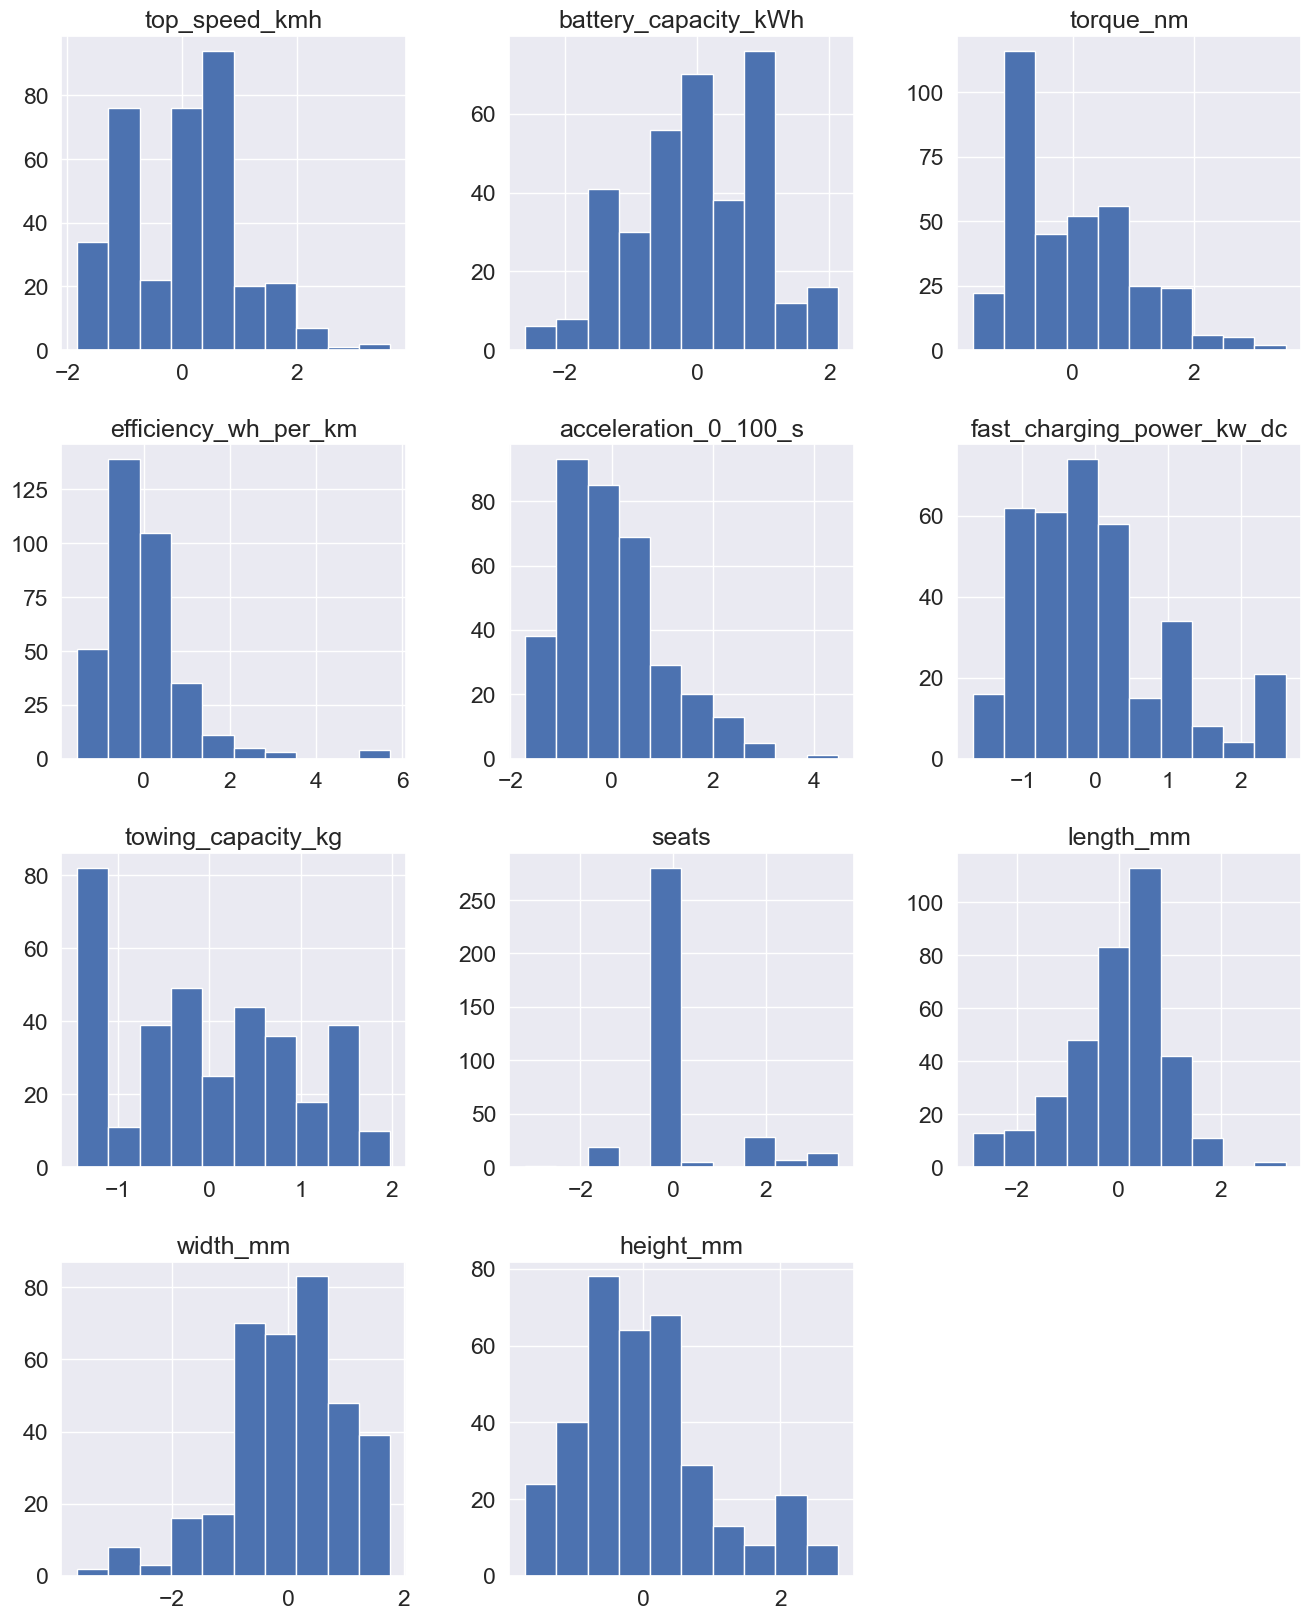

In [52]:
# 독립 변수 탐색
fig = plt.figure(figsize = (16, 20))
ax = fig.gca()  
X_train[scale_columns].hist(ax=ax)
plt.show()

In [53]:
X_train[scale_columns].head()

,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
73,0.897746,0.822734,0.779480,0.483705,-0.871680,0.639275,0.608213,-0.305614,0.368475,0.485346,0.091370
39,0.140254,-0.361616,-0.442894,0.260760,-0.322733,-0.555709,0.745388,-0.305614,0.241923,-0.509395,-1.201475
185,-0.768736,-0.513330,-1.007716,-0.435942,0.409196,-0.470353,-0.420598,-0.305614,-0.008490,-0.400382,-0.058961
435,-0.162743,0.122891,0.189368,-0.909700,-0.139751,-0.043573,-0.077661,-0.305614,0.721207,-0.373129,-0.540020
313,-1.617127,-1.198491,-0.990856,-0.324470,1.763265,-0.811777,-0.420598,1.620847,0.166530,0.430839,1.722458


In [54]:
y_train

73     430
39     430
185    365
435    475
313    230
      ... 
326    495
24     395
75     360
17     435
182    310
Name: range_km, Length: 353, dtype: int64

In [55]:
X_train

,top_speed_kmh,battery_capacity_kWh,torque_nm,efficiency_wh_per_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm,drivetrain_FWD,drivetrain_RWD,segment_Medium,segment_Small
73,0.897746,0.822734,0.779480,0.483705,-0.871680,0.639275,0.608213,-0.305614,0.368475,0.485346,0.091370,0,0,0,0
39,0.140254,-0.361616,-0.442894,0.260760,-0.322733,-0.555709,0.745388,-0.305614,0.241923,-0.509395,-1.201475,0,1,0,0
185,-0.768736,-0.513330,-1.007716,-0.435942,0.409196,-0.470353,-0.420598,-0.305614,-0.008490,-0.400382,-0.058961,1,0,1,0
435,-0.162743,0.122891,0.189368,-0.909700,-0.139751,-0.043573,-0.077661,-0.305614,0.721207,-0.373129,-0.540020,0,1,0,0
313,-1.617127,-1.198491,-0.990856,-0.324470,1.763265,-0.811777,-0.420598,1.620847,0.166530,0.430839,1.722458,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,-0.162743,0.954872,-0.683154,-0.212998,0.189617,0.127139,0.608213,-0.305614,0.392709,1.616352,-0.479887,0,1,0,0
24,0.746247,0.064163,-0.232140,0.037815,0.043232,0.383207,1.294088,-0.305614,0.209611,0.676118,0.579945,0,1,0,0
75,-0.768736,-0.758030,-0.822252,-0.240866,-0.066558,-0.299641,-1.449410,-0.305614,-0.999369,-1.095338,-0.509953,0,1,1,0
17,-0.162743,0.122891,0.168293,-0.073657,-0.066558,-0.128929,-0.077661,-0.305614,-0.283136,-0.332249,0.046270,0,1,1,0


다중공선성 확인

In [56]:
# 다중공선성 검사 (VIF)
vif = pd.DataFrame()
vif['features'] = X_train.columns
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) 
                    for i in range(X_train.shape[1])]
vif.round(1) 

,features,VIF Factor
0,top_speed_kmh,7.5
1,battery_capacity_kWh,4.7
2,torque_nm,5.8
3,efficiency_wh_per_km,2.9
4,acceleration_0_100_s,7.7
5,fast_charging_power_kw_dc,3.6
6,towing_capacity_kg,1.8
7,seats,3.8
8,length_mm,7.5
9,width_mm,6.2


In [57]:
# 인덱스 재정렬
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

회귀 모델링

In [58]:
# train 데이터로 선형 회귀 모델 학습
lr = linear_model.LinearRegression()
model = lr.fit(X_train, y_train)

# test 데이터로 예측
pred_test = lr.predict(X_test)

In [59]:
# 회귀 계수 출력
print(lr.coef_)

[-13.85264546  92.43087198  -0.11169087 -19.34530468 -10.0865092
   2.61004707   8.04926816  -1.1881896   16.78291894  -9.54911691
 -35.44043751  15.54027074  28.57689921   1.74789052 -14.3638399 ]


In [60]:
# 회귀 계수를 데이터프레임으로 정리
coefs = pd.DataFrame(zip(X_train.columns, lr.coef_), 
                    columns=['feature', 'coefficients'])
coefs

,feature,coefficients
0,top_speed_kmh,-13.852645
1,battery_capacity_kWh,92.430872
2,torque_nm,-0.111691
3,efficiency_wh_per_km,-19.345305
4,acceleration_0_100_s,-10.086509
5,fast_charging_power_kw_dc,2.610047
6,towing_capacity_kg,8.049268
7,seats,-1.188190
8,length_mm,16.782919
9,width_mm,-9.549117


In [61]:
# 회귀 계수를 크기 순서대로 나열
coefs_new = coefs.reindex(coefs.coefficients.abs().
                          sort_values(ascending=False).index)
coefs_new

,feature,coefficients
1,battery_capacity_kWh,92.430872
10,height_mm,-35.440438
12,drivetrain_RWD,28.576899
3,efficiency_wh_per_km,-19.345305
8,length_mm,16.782919
11,drivetrain_FWD,15.540271
14,segment_Small,-14.363840
0,top_speed_kmh,-13.852645
4,acceleration_0_100_s,-10.086509
9,width_mm,-9.549117


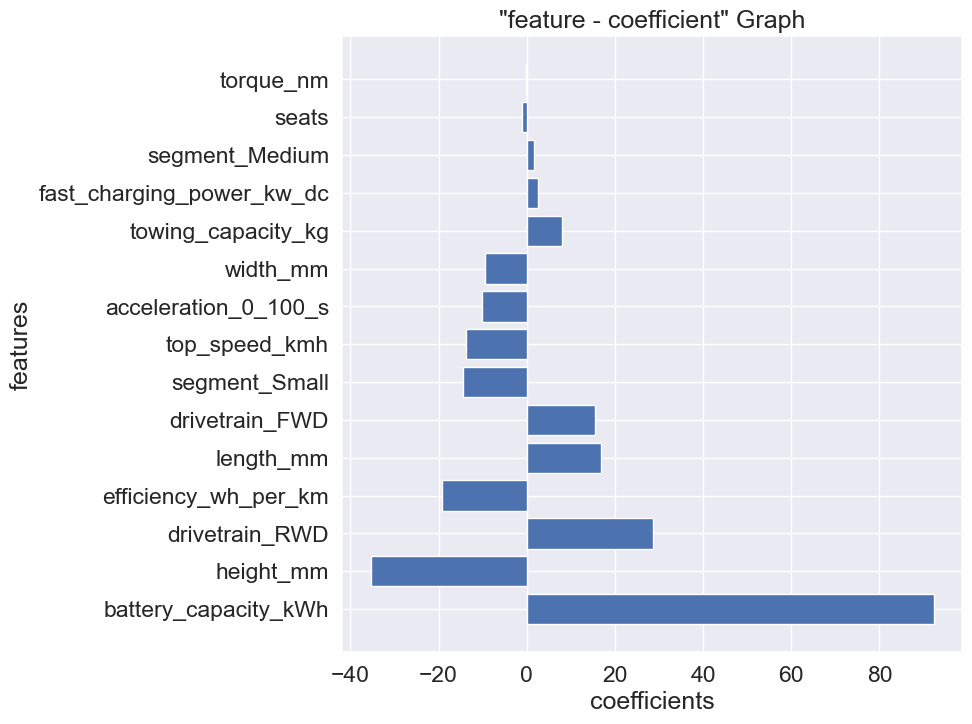

In [62]:
# 회귀 계수 시각화
plt.figure(figsize = (8, 8))

plt.barh(coefs_new['feature'], coefs_new['coefficients'])
plt.title('"feature - coefficient" Graph')
plt.xlabel('coefficients') 
plt.ylabel('features')
plt.show()

In [63]:
# 회귀 분석 모형 수식 간단하게 만들기 위해 독립변수 데이터에 상수항 추가
X_train2 = sm.add_constant(X_train)

# OLS 
model2 = sm.OLS(y_train, X_train2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               range_km   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     530.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          6.18e-224
Time:                        22:54:07   Log-Likelihood:                -1579.7
No. Observations:                 353   AIC:                             3191.
Df Residuals:                     337   BIC:                             3253.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                       382.3555      3.741    102.215      0.000     374.997     389.714
top_speed_kmh               -13.8526      3.232     -4.286      0.000     -20.210      -7.495
battery_capacity_kWh         92.4309      2.515     36.750      0.000      87.484      97.378
torque_nm                    -0.1117      3.226     -0.035      0.972      -6.457       6.233
efficiency_wh_per_km        -19.3453      1.987     -9.737      0.000     -23.253     -15.437
acceleration_0_100_s        -10.0865      3.268     -3.086      0.002     -16.515      -3.658
fast_charging_power_kw_dc     2.6100      2.237      1.167      0.244      -1.789       7.009
towing_capacity_kg            8.0493      1.640      4.907      0.000       4.823      11.276
seats                        -1.1882      2.244     -0.529      0.597      -5.603       3.227
length_mm                    16.7829      3.265      5.140      0.000      10.360      23.206
width_mm                     -9.5491      2.901     -3.292      0.001     -15.255      -3.844
height_mm                   -35.4404      2.535    -13.982      0.000     -40.426     -30.454
drivetrain_FWD               15.5403      6.505      2.389      0.017       2.745      28.335
drivetrain_RWD               28.5769      4.418      6.468      0.000      19.886      37.268
segment_Medium                1.7479      3.915      0.446      0.656      -5.954       9.449
segment_Small               -14.3638      6.867     -2.092      0.037     -27.872      -0.856
==============================================================================
Omnibus:                        6.925   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.031   Jarque-Bera (JB):                6.827
Skew:                           0.337   Prob(JB):                       0.0329
Kurtosis:                       3.098   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [64]:
# 예측값과 실제값 비교
df_pred1 = pd.DataFrame({'actual': y_test, 'prediction': pred_test})
df_pred1 = df_pred1.sort_values(by='actual').reset_index(drop=True)
df_pred1.head()

,actual,prediction
0,180,183.455952
1,215,178.981588
2,225,203.193484
3,225,205.334420
4,230,235.993911


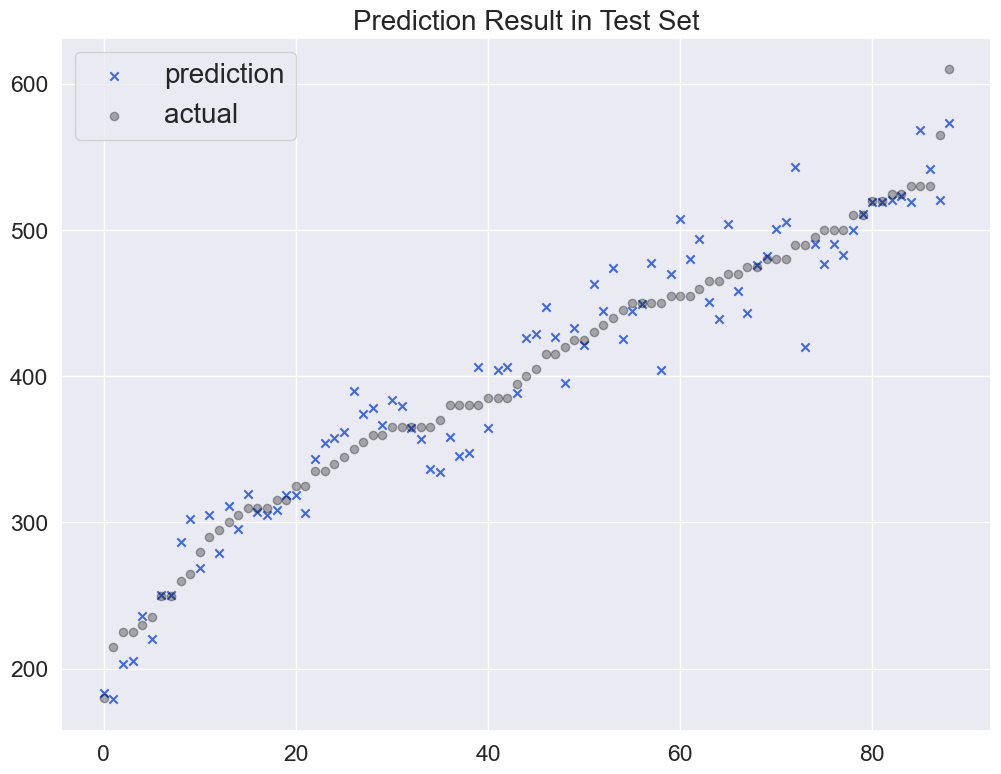

In [65]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(12, 9))
plt.scatter(df_pred1.index, df_pred1['prediction'], marker='x', color='royalblue')
plt.scatter(df_pred1.index, df_pred1['actual'], alpha=0.3, marker='o', color='black')
plt.title("Prediction Result in Test Set", fontsize=20)
plt.legend(['prediction', 'actual'], fontsize=20)
plt.show()

p-value가 0.05보다 큰 변수 삭제한 버전

In [66]:
# 유의하지 않은 변수 제거 (p-value > 0.05)
drop_cols = ['torque_nm', 'fast_charging_power_kw_dc', 'seats', 'segment_Medium']
X_train_remove = X_train.drop(columns=drop_cols)
X_test_remove = X_test.drop(columns=drop_cols)

In [67]:
# p-value > 0.05인 변수 제거 후, 선형 회귀 모델 학습 및 예측
lr2 = linear_model.LinearRegression()

model2 = lr2.fit(X_train_remove, y_train)
pred_test2 = lr2.predict(X_test_remove)

In [68]:
# 회귀 계수 출력
print(lr2.coef_)

[-12.38122606  93.26568827 -19.64688729  -9.77236688   7.77743989
  15.29664848  -9.0563034  -36.00653393  14.22830981  28.60056303
 -16.4545206 ]


In [69]:
# 회귀 계수를 데이터프레임으로 정리
coefs = pd.DataFrame(zip(X_train_remove.columns, lr2.coef_), 
                    columns=['feature', 'coefficients'])
coefs

,feature,coefficients
0,top_speed_kmh,-12.381226
1,battery_capacity_kWh,93.265688
2,efficiency_wh_per_km,-19.646887
3,acceleration_0_100_s,-9.772367
4,towing_capacity_kg,7.777440
5,length_mm,15.296648
6,width_mm,-9.056303
7,height_mm,-36.006534
8,drivetrain_FWD,14.228310
9,drivetrain_RWD,28.600563


In [70]:
# 회귀 계수를 크기 순서대로 나열
coefs_new = coefs.reindex(coefs.coefficients.abs().
                          sort_values(ascending=False).index)
coefs_new

,feature,coefficients
1,battery_capacity_kWh,93.265688
7,height_mm,-36.006534
9,drivetrain_RWD,28.600563
2,efficiency_wh_per_km,-19.646887
10,segment_Small,-16.454521
5,length_mm,15.296648
8,drivetrain_FWD,14.228310
0,top_speed_kmh,-12.381226
3,acceleration_0_100_s,-9.772367
6,width_mm,-9.056303


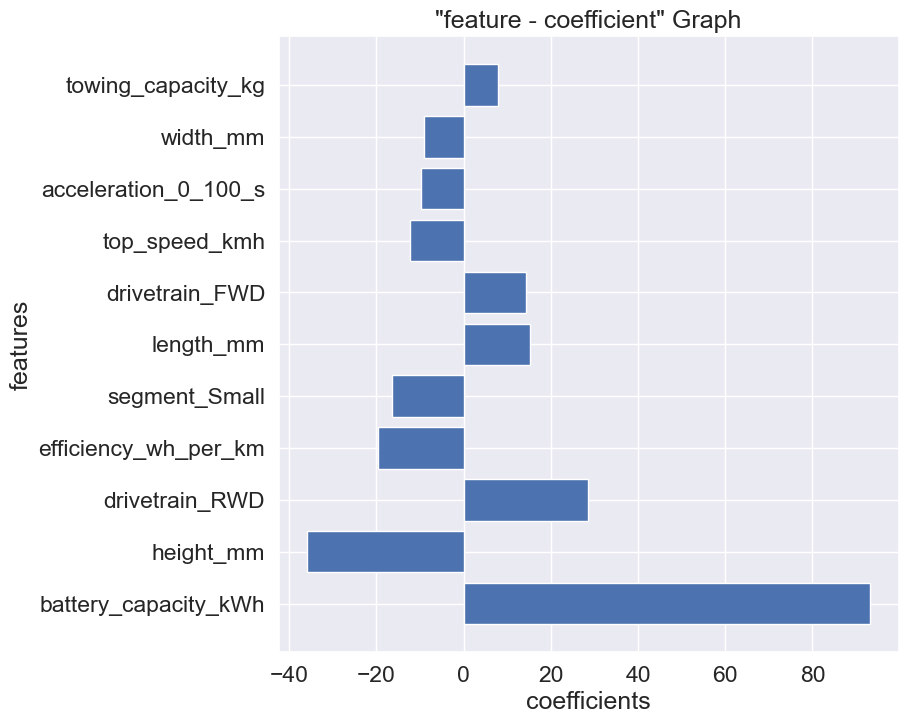

In [71]:
# 회귀 계수 시각화
plt.figure(figsize = (8, 8))
plt.barh(coefs_new['feature'], coefs_new['coefficients'])
plt.title('"feature - coefficient" Graph')
plt.xlabel('coefficients')
plt.ylabel('features')
plt.show()

In [72]:
# 상수항 추가
X_train_remove2 = sm.add_constant(X_train_remove)

# OLS
model_ols = sm.OLS(y_train, X_train_remove2).fit()
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               range_km   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     727.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          3.16e-229
Time:                        22:54:09   Log-Likelihood:                -1580.6
No. Observations:                 353   AIC:                             3185.
Df Residuals:                     341   BIC:                             3232.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  383.5137      2.791    137.404      0.000     378.024     389.004
top_speed_kmh          -12.3812      2.663     -4.649      0.000     -17.619      -7.143
battery_capacity_kWh    93.2657      2.289     40.747      0.000      88.764      97.768
efficiency_wh_per_km   -19.6469      1.940    -10.129      0.000     -23.462     -15.832
acceleration_0_100_s    -9.7724      3.025     -3.230      0.001     -15.723      -3.821
towing_capacity_kg       7.7774      1.584      4.910      0.000       4.662      10.893
length_mm               15.2966      2.813      5.438      0.000       9.763      20.830
width_mm                -9.0563      2.728     -3.320      0.001     -14.421      -3.691
height_mm              -36.0065      2.356    -15.282      0.000     -40.641     -31.372
drivetrain_FWD          14.2283      5.717      2.489      0.013       2.984      25.473
drivetrain_RWD          28.6006      3.520      8.125      0.000      21.677      35.524
segment_Small          -16.4545      5.002     -3.290      0.001     -26.293      -6.616
==============================================================================
Omnibus:                        5.553   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.062   Jarque-Bera (JB):                5.534
Skew:                           0.307   Prob(JB):                       0.0628
Kurtosis:                       2.997   Cond. No.                         12.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [73]:
# 예측값과 실제값 비교
df_pred2 = pd.DataFrame({'actual': y_test, 'prediction': pred_test2})
df_pred2 = df_pred2.sort_values(by='actual').reset_index(drop=True)
df_pred2.head()

,actual,prediction
0,180,182.740405
1,215,179.155952
2,225,202.759304
3,225,204.716957
4,230,236.327428


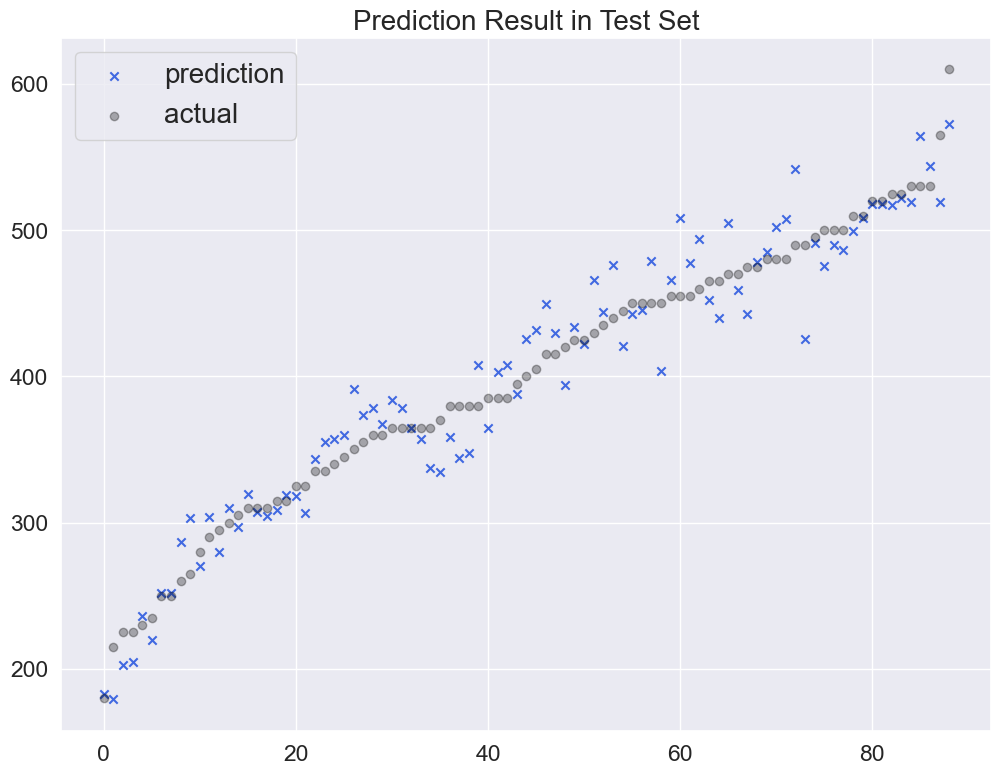

In [74]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(12, 9))
plt.scatter(df_pred2.index, df_pred2['prediction'], marker='x', color='royalblue')
plt.scatter(df_pred2.index, df_pred2['actual'], alpha=0.3, marker='o', color='black')
plt.title("Prediction Result in Test Set", fontsize=20)
plt.legend(['prediction', 'actual'], fontsize=20)
plt.show()

In [75]:
# p-value 제거 전 모델 성능 평가
pred_train = lr.predict(X_train)

print('[p-value 제거 전]')
print('R-Squared')
print(lr.score(X_train, y_train)) # training set
print(lr.score(X_test, y_test)) # test set

print('\nRSS')
print(np.sum((y_train - pred_train)**2)) # training set
print(np.sum((y_test - pred_test)**2)) # test set

print('\nMSE')
print(mean_squared_error(y_train, pred_train)) # training set
print(mean_squared_error(y_test, pred_test)) # test set

print('\nRMSE')
print(sqrt(mean_squared_error(y_train, pred_train))) # training set
print(sqrt(mean_squared_error(y_test, pred_test))) # test set

[p-value 제거 전]
R-Squared
0.9593399041249645
0.9368253023149439

RSS
159351.33305629468
48138.94217899681

MSE
451.42020695834185
540.8869907752451

RMSE
21.24665166463511
23.256977249316925


In [76]:
# p-value 제거 후 모델의 성능 평가
pred_train2 = lr2.predict(X_train_remove)

print('[p-value 제거 후]')
print('R-Squared')
print(lr2.score(X_train_remove, y_train)) # training set
print(lr2.score(X_test_remove, y_test)) # test set

print('\nRSS')
print(np.sum((y_train - pred_train2)**2)) # training set
print(np.sum((y_test - pred_test2)**2)) # test set

print('\nMSE')
print(mean_squared_error(y_train, pred_train2)) # training set
print(mean_squared_error(y_test, pred_test2)) # test set

print('\nRMSE')
print(sqrt(mean_squared_error(y_train, pred_train2))) # training set
print(sqrt(mean_squared_error(y_test, pred_test2))) # test set

[p-value 제거 후]
R-Squared
0.9591401562835494
0.9358415099152201

RSS
160134.16654745117
48888.589224124524

MSE
453.6378655735161
549.309991282298

RMSE
21.298776152012024
23.437363146956145


In [77]:
# Cross Validation
# n_splits=10 : 훈련 데이터를 10등분
# shuffle=True : 분할 전 데이터를 무작위로 섞음
# random_state=2 : 재현 가능한 결과를 위한 난수 고정
# iloc → 순서 위치 기반
kf = KFold(n_splits=10, shuffle=True, random_state=2)

# 각 fold의 성능 지표를 저장할 리스트
R_squ_history_cv = []
RSS_history_cv = []
MSE_history_cv = []
RMSE_history_cv = []

# k겹 교차 검증 수행
# 매 반복마다 훈련 데이터를 train fold(학습)와 val fold(검증)로 다르게 분리
for train_index, val_index in kf.split(X_train_remove):

    # 훈련 데이터를 학습용 fold와 검증용 fold로 분리
    # test 데이터는 CV에 사용하지 않음
    X_fold_train = X_train_remove.iloc[train_index]  # 학습 fold (90%)
    X_fold_val   = X_train_remove.iloc[val_index]    # 검증 fold (10%)
    y_fold_train = y_train.iloc[train_index]
    y_fold_val   = y_train.iloc[val_index]

    # 매 fold마다 모델을 새로 학습
    # 이전 fold의 영향을 받지 않기 위해 새 모델 인스턴스 생성
    lr_cv = linear_model.LinearRegression()
    lr_cv.fit(X_fold_train, y_fold_train)

    # 이번 fold에서 학습하지 않은 검증 fold로 예측
    cv_pred = lr_cv.predict(X_fold_val)

    # 성능 지표 계산 후 리스트에 저장
    R_squ_history_cv.append(r2_score(y_fold_val, cv_pred))
    RSS_history_cv.append(np.sum((y_fold_val - cv_pred)**2))
    MSE_history_cv.append(mean_squared_error(y_fold_val, cv_pred))
    RMSE_history_cv.append(sqrt(mean_squared_error(y_fold_val, cv_pred)))

In [78]:
# 모델의 성능 평가
pred_train2 = lr2.predict(X_train_remove)

print('R-Squared')
print(f'Training Set: {round(lr2.score(X_train_remove, y_train), 4)}')
print(f'10-Fold Cross Validation: {round(np.mean(R_squ_history_cv), 4)}')
print(f'Test Set: {round(lr2.score(X_test_remove, y_test), 4)}')

print('\nRSS')
print(f'Training Set: {round(np.sum((y_train - pred_train2)**2), 4)}')
print(f'10-Fold Cross Validation: {round(np.mean(RSS_history_cv), 4)}')
print(f'Test Set: {round(np.sum((y_test - pred_test2)**2), 4)}')

print('\nRMSE')
print(f'Training Set: {round(sqrt(mean_squared_error(y_train, pred_train2)), 4)}')
print(f'10-Fold Cross Validation: {round(np.mean(RMSE_history_cv), 4)}')
print(f'Test Set: {round(sqrt(mean_squared_error(y_test, pred_test2)), 4)}')

R-Squared
Training Set: 0.9591
10-Fold Cross Validation: 0.954
Test Set: 0.9358

RSS
Training Set: 160134.1665
10-Fold Cross Validation: 17336.9024
Test Set: 48888.5892

RMSE
Training Set: 21.2988
10-Fold Cross Validation: 22.032
Test Set: 23.4374


In [79]:
# 앞서 만든 모델 중 가장 영향력이 큰 battery_capacity_kWh 단일 변수 모델
X_simple = X_train_remove[['battery_capacity_kWh']]
X_simple_test = X_test_remove[['battery_capacity_kWh']]

lr_simple = linear_model.LinearRegression()
lr_simple.fit(X_simple, y_train)

pred_simple = lr_simple.predict(X_simple_test)

# 앞서 만든 모델 중 가장 영향력이 큰 battery_capacity_kWh 단일 변수 모델의 성능 평가
print('단순 모델 (battery_capacity_kWh만 사용)')
print(f'R-Squared: {round(lr_simple.score(X_simple_test, y_test), 4)}')
print(f'RSS: {round(np.sum((y_test - pred_simple)**2), 4)}')
print(f'MSE: {round(mean_squared_error(y_test, pred_simple), 4)}')
print(f'RMSE: {round(sqrt(mean_squared_error(y_test, pred_simple)), 4)}')

단순 모델 (battery_capacity_kWh만 사용)
R-Squared: 0.7645
RSS: 179440.684
MSE: 2016.1875
RMSE: 44.902


In [80]:
# 모델 성능 비교 표
performance = pd.DataFrame({
    'Training Set': [
        round(lr2.score(X_train_remove, y_train), 4),
        round(np.sum((y_train - pred_train2)**2), 4),
        round(mean_squared_error(y_train, pred_train2), 4),
        round(sqrt(mean_squared_error(y_train, pred_train2)), 4)
    ],
    '10-Fold CV': [
        round(np.mean(R_squ_history_cv), 4),
        round(np.mean(RSS_history_cv), 4),
        round(np.mean(MSE_history_cv), 4),
        round(np.mean(RMSE_history_cv), 4)
    ],
    'Test Set': [
        round(lr2.score(X_test_remove, y_test), 4),
        round(np.sum((y_test - pred_test2)**2), 4),
        round(mean_squared_error(y_test, pred_test2), 4),
        round(sqrt(mean_squared_error(y_test, pred_test2)), 4)
    ]
}, index=['R²', 'RSS', 'MSE', 'RMSE'])

performance.T

,R²,RSS,MSE,RMSE
Training Set,0.9591,160134.1665,453.6379,21.2988
10-Fold CV,0.9540,17336.9024,491.6343,22.0320
Test Set,0.9358,48888.5892,549.3100,23.4374


In [81]:
# 단순 모델 vs 최종 모델 성능 비교 표
comparison = pd.DataFrame({
    '단순 모델 (battery_capacity_kWh)': [
        round(lr_simple.score(X_simple_test, y_test), 4),
        round(np.sum((y_test - pred_simple)**2), 4),
        round(mean_squared_error(y_test, pred_simple), 4),
        round(sqrt(mean_squared_error(y_test, pred_simple)), 4)
    ],
    '최종 모델 (변수 11개)': [
        round(lr2.score(X_test_remove, y_test), 4),
        round(np.sum((y_test - pred_test2)**2), 4),
        round(mean_squared_error(y_test, pred_test2), 4),
        round(sqrt(mean_squared_error(y_test, pred_test2)), 4)
    ]
}, index=['R²', 'RSS', 'MSE', 'RMSE'])

# 행열 전치 (모델이 행, 지표가 열)
comparison.T

,R²,RSS,MSE,RMSE
단순 모델 (battery_capacity_kWh),0.7645,179440.6840,2016.1875,44.9020
최종 모델 (변수 11개),0.9358,48888.5892,549.3100,23.4374
